In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL and AML as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

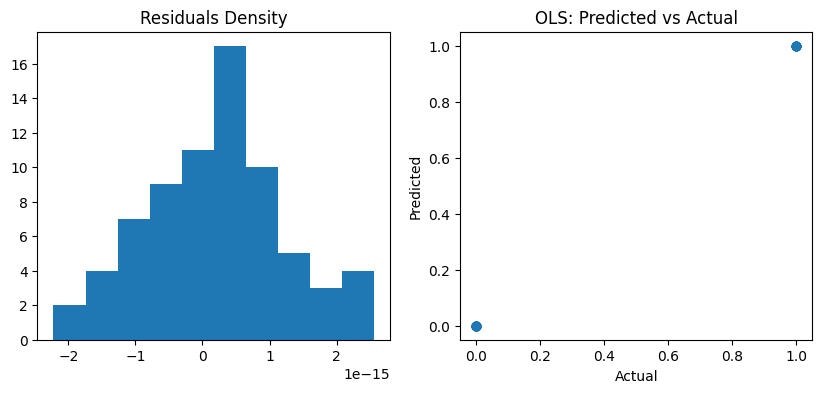

Mean-Squared Error: 1.1098492292855512e-30


In [11]:
# (1)
# read the dataset
_df = pd.read_csv("../data/golub.csv")
_target_map = {"allb": 0, "allt": 0, "all": 1, "aml": 1}
# so i pulled some shenanigans b/c i couldn't find a codebook for the dataset in the first 20 google searches.
# first we copy the data
_df_clean = _df.copy()
# then we standardize the text
_df_clean["target"] = _df_clean["cancer"].str.lower().map(_target_map)
# drop any values that don't have a target value and copy it
_df_clean = _df_clean.dropna(subset=["target"]).copy()

# normal assignment
y = _df_clean["target"]
X = _df_clean.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"])
# i just fabricated the data by taking the mean of what was there. the NaN issue is beyond me.
X = X.fillna(X.mean())

# (2)
model_lr = LinearRegression().fit(X, y)
preds_lr = model_lr.predict(X)
mse_lr = mean_squared_error(y, preds_lr)

_fig, _ax = plt.subplots(1, 2, figsize=(10, 4))
_resids = y - preds_lr
if np.var(_resids) > 1e-15:
    sns.kdeplot(_resids, ax=_ax[0], fill=True)
else:
    _ax[0].hist(_resids)
_ax[0].set_title("Residuals Density")
_ax[1].scatter(y, preds_lr, alpha=0.5)
_ax[1].set_xlabel("Actual")
_ax[1].set_ylabel("Predicted")
_ax[1].set_title("OLS: Predicted vs Actual")
plt.show()

print(f"Mean-Squared Error: {mse_lr}")

In [12]:
# (3)
_cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_lr = -np.mean(_cv_scores)
print(f"Cross-Validated Mean-Squared Error: {cv_mse_lr}")

Cross-Validated Mean-Squared Error: 0.06012309872062149


The training MSE is essentially zero or insignificant, but the cross-validated MSE is significantly higher (when comparing $6 \cdot 10^{-2}$ vs $1 \cdot 10^{-30}$, that's a difference of $10^{28}$). This difference is the bias-variance trade-off, because OLS in high dimensions ($p \gg n$) has zero bias but high variance, causing it to overfit training noise and generalize on testing data.

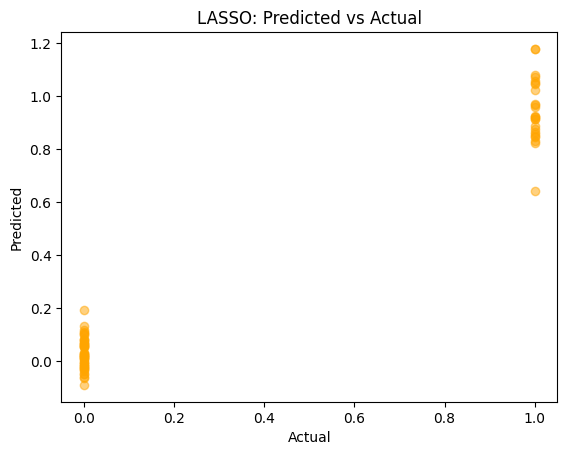

Selected Genes (34): ['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']
Genes Discarded: 7095


In [9]:
# (4)
model_lasso = LassoCV(cv=5).fit(X, y)
selected_genes = X.columns[model_lasso.coef_ != 0].tolist()
discarded_count = (model_lasso.coef_ == 0).sum()
preds_lasso = model_lasso.predict(X)

plt.figure()
plt.scatter(y, preds_lasso, alpha=0.5, color='orange')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO: Predicted vs Actual")
plt.show()

print(f"Selected Genes ({len(selected_genes)}): {selected_genes}")
print(f"Genes Discarded: {discarded_count}")

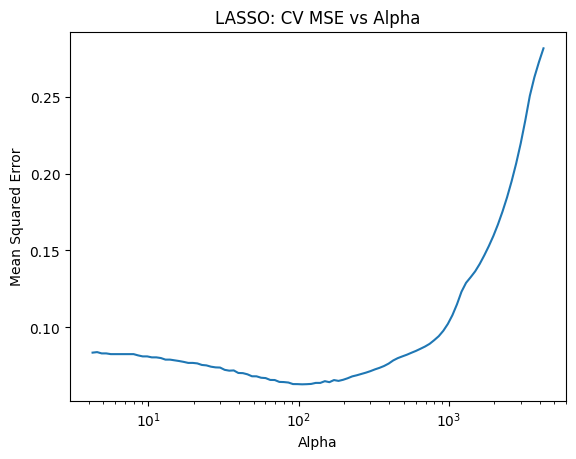

Optimal Alpha: 105.24436668425457


In [13]:
# (5)
_mse_path = np.mean(model_lasso.mse_path_, axis=1)
plt.figure()
plt.plot(model_lasso.alphas_, _mse_path)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('LASSO: CV MSE vs Alpha')
plt.show()

print(f"Optimal Alpha: {model_lasso.alpha_}")

The LASSO overfits around low $\alpha$ values where the OLS approaches instability. It underfits at high $\alpha$ values where the penalty is too strong which brings the coefficients closer to zero and increasing bias. The optimal $\alpha$ minimizes the expected Mean-Squared Error by finding the sweet spot between these two extremes.

### (6)
Linear regression is succesfully utilized on the training set because with $p > n$, the model has the proper degrees of freedom to output each data point precisely; however, it also captures training dataset noise as if there is importance in features that don't exist. LASSO is better at generalizing from training data due to $L_1$ regularization selecting features and shrinking coefficients. This dramatically reduces the model variance at the cost of some bias.

### (7)
Regularization is optimal for precision health due to genomic datasets being higher in dimensionality but limited in values as only a few genes typically are involved with the disease. This allows the model to focus on the relevant biomarkers while ignoring the noise which results in more accurate predictions.

### (8)
Risks include selection instability (LASSO selecting only one gene from a group of highly correlated genes and discarding the rest) and omission of cumulative effects. If medical decisions are made based on a sparse model, practicing physicians will overlook more minute details that may have much larger impacts on the patient's health.